In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pickle

with open('../data/processed/team_matches.pkl', 'rb') as f:
    team_matches = pickle.load(f)
                 
with open('../data/raw/european_leagues_data.pkl', 'rb') as f:
    all_matches = pickle.load(f)

In [29]:
print(team_matches['league'].unique())
print(team_matches['season'].unique())

<StringArray>
['Serie_A', 'Premier_League', 'La_Liga', 'Bundesliga', 'Ligue_1']
Length: 5, dtype: str
<StringArray>
['2526', '2425', '2324', '2223', '2122', '2021', '1920', '1819', '1718',
 '1617', '1516', '1415', '1314', '1213', '1112']
Length: 15, dtype: str


# Fouls, Cards and Randomness: a statistical analysis of fouls in Serie A


## Introduction

Football is a sport where players tries to follow their manager's instruction while taking  split-second decisions, charged with adrenaline while watched from their fans (and opposite fan). But most of the time we forget one of the ingredients that makes this game loved by so many people: a fair amount of pure luck. A late tackle, a raised elbow, a foot that stayed on the ground half a second too long: fouls seem almost random, yet they tell us something systematic about how a team plays.

In this notebook we will analyse fouls committed and received in Serie A during the 2025/26 season (still ongoing). The aim is not just to answer questions about the league but also using football data to explain how statistical reasoning works: why we use certain tools, when they work, and when they lead us astray.

We will follow a deliberately iterative approach: we show every step, including the wrong ones, because that is how data analysis actually works — not how it appears in scientific papers.

> **Note:** The data covers the 2025/26 Italian Serie A season up to the matchday available at the time of analysis, i.e 22/03/2026. Results are therefore partial by definition.


In [37]:
ita_2526 = team_matches[
    (team_matches['league'] == 'Serie_A') &
    (team_matches['season'] == '2526')
].copy()

dates = pd.to_datetime(ita_2526['date'], dayfirst=True)

print(f"Rows loaded: {len(ita_2526)}")
print(f"Matches played: {len(ita_2526) // 2}")
print(f"Teams: {ita_2526['team'].nunique()}")
print(f"Date range: {dates.min().strftime('%d/%m/%Y')} → {dates.max().strftime('%d/%m/%Y')}")
ita_2526.head()


Rows loaded: 600
Matches played: 300
Teams: 20
Date range: 23/08/2025 → 22/03/2026


,season,date,team,opponent,yellow_cards,red_cards,fouls_committed,fouls_received,shots,shots_opponent,shots_on_target,shots_on_target_opponent,corners,corners_opponent,goals_scored,goals_conceded,match_result,venue,team_result,league
0,2526,23/08/2025,Genoa,Lecce,2.0,0.0,16.0,13.0,5.0,7.0,2.0,0.0,3.0,7.0,0.0,0.0,D,home,D,Serie_A
1,2526,23/08/2025,Sassuolo,Napoli,3.0,1.0,17.0,17.0,7.0,13.0,2.0,4.0,1.0,2.0,0.0,2.0,A,home,L,Serie_A
2,2526,23/08/2025,Milan,Cremonese,1.0,0.0,10.0,14.0,24.0,4.0,6.0,3.0,9.0,2.0,1.0,2.0,A,home,L,Serie_A
3,2526,23/08/2025,Roma,Bologna,1.0,0.0,15.0,13.0,14.0,10.0,4.0,2.0,2.0,4.0,1.0,0.0,H,home,W,Serie_A
4,2526,24/08/2025,Cagliari,Fiorentina,4.0,0.0,18.0,14.0,14.0,4.0,6.0,1.0,3.0,2.0,1.0,1.0,D,home,D,Serie_A


A quick note on the data structure: each match appears **twice** in the dataframe: once for each team's perspective. So Genoa vs Lecce generates one row where Genoa's fouls are `fouls_committed`, and one where Lecce's are. This is intentional: it lets us treat every team symmetrically without reshaping the data later.

## 1. How are fouls distributed?

Before asking whether teams differ from each other, we need to understand the overall shape of the data. How many fouls are typically committed in a Serie A match? Is the distribution symmetric? Are there outliers?

We start with the simplest possible question: if you picked a random Serie A match from this season, how many fouls would you expect to see from one team?

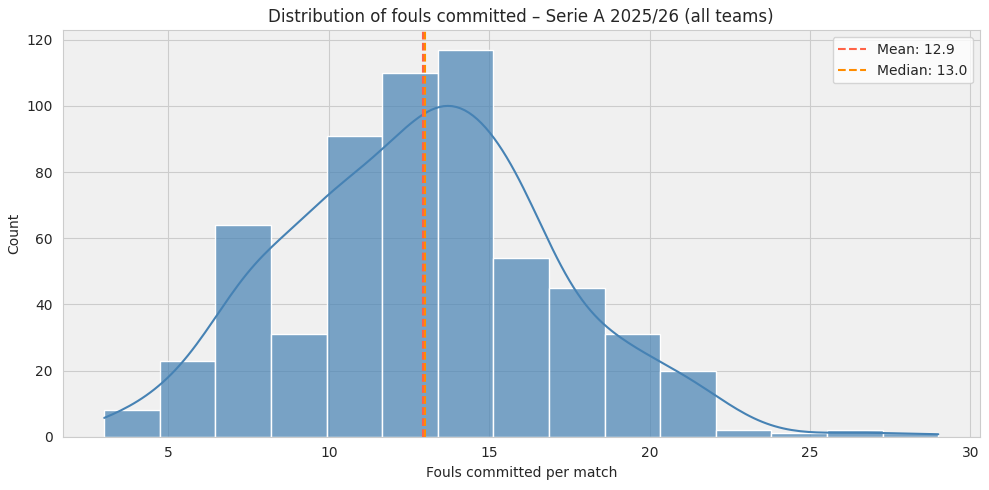

In [44]:
with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_facecolor('#f0f0f0')
    
    sns.histplot(ita_2526['fouls_committed'], 
                 bins=15, 
                 kde=True,
                 color='steelblue', 
                 alpha=0.7, 
                 ax=ax)
    
    ax.axvline(ita_2526['fouls_committed'].mean(), color='tomato', 
               linestyle='--', linewidth=1.5, label=f"Mean: {ita_2526['fouls_committed'].mean():.1f}")
    ax.axvline(ita_2526['fouls_committed'].median(), color='darkorange', 
               linestyle='--', linewidth=1.5, label=f"Median: {ita_2526['fouls_committed'].median():.1f}")
    
    ax.set_xlabel('Fouls committed per match')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of fouls committed – Serie A 2025/26 (all teams)')
    ax.legend()
    plt.tight_layout()


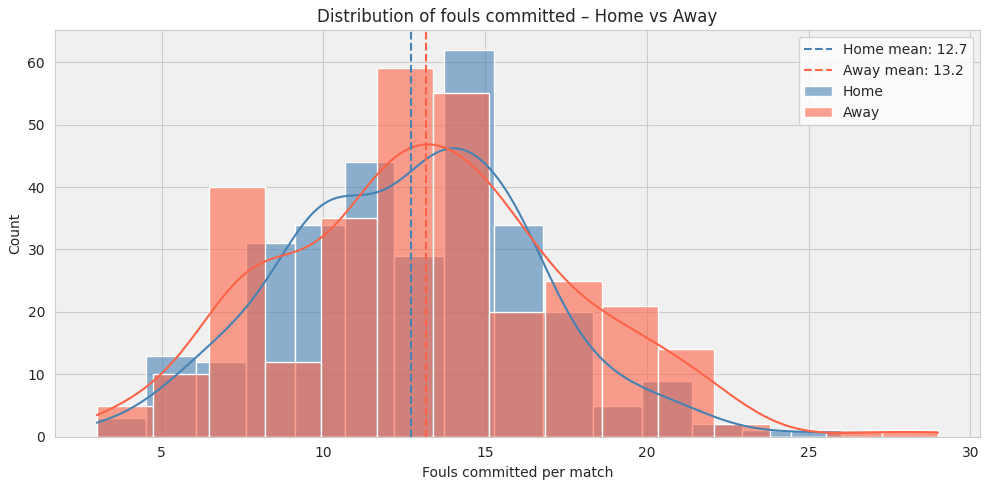

In [46]:
home = ita_2526[ita_2526['venue'] == 'home']['fouls_committed']
away = ita_2526[ita_2526['venue'] == 'away']['fouls_committed']

with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_facecolor('#f0f0f0')

    sns.histplot(home, bins=15, kde=True, color='steelblue', alpha=0.6, label='Home', ax=ax)
    sns.histplot(away, bins=15, kde=True, color='tomato', alpha=0.6, label='Away', ax=ax)

    ax.axvline(home.mean(), color='steelblue', linestyle='--', linewidth=1.5,
               label=f'Home mean: {home.mean():.1f}')
    ax.axvline(away.mean(), color='tomato', linestyle='--', linewidth=1.5,
               label=f'Away mean: {away.mean():.1f}')

    ax.set_xlabel('Fouls committed per match')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of fouls committed – Home vs Away')
    ax.legend()
    plt.tight_layout()



### What do we see?

The overall distribution is roughly bell-shaped, centred around **13 fouls per match**. Mean (12.9) and median (13.0) values are also very close and this is very telling. When mean and median are this close, it is in fact a first signal that the distribution is fairly symmetric, without extreme values pulling the average in one direction.

There is a mild right tail, some occasional matches where a team commits more than 25 fouls. But broadly, fouls in Serie A cluster predictably around that 13-foul mark.

Now look at the home vs. away split. Two things stand out immediately:

- **Away teams commit more fouls**: the red distribution is shifted to the right relative to the blue one.
- **The away distribution is wider and more skewed**: away teams are not just fouling more on average, they are also more variable — some away sides barely foul, others rack up big numbers.

At first glance, you might be tempted to compare the two peaks and call it a day. 
Don't do that.

Look more carefully at the blue (home) curve. There is a secondary bump around 10 fouls — 
a shoulder on the left side of the main peak — before the distribution rises to its maximum 
around 14. That leftward pull is what drags the home mean *down*, even though the two peaks 
are at similar heights. The home curve is also asymmetric in the other direction: it drops 
sharply after the peak, with few home teams racking up very high foul counts.

The away curve tells a different story: it rises more steeply, peaks slightly higher, and 
has a longer right tail — meaning away teams are not just fouling more on average, they also 
occasionally have very high-foul matches.

This is a good reminder that two distributions can look similar at a glance and still behave 
quite differently. Summary statistics like mean and median help, but they are no substitute for  looking at the full shape.

A small but important observation: the combined distribution (all teams, first plot) looks *more normal* than either the home or away distributions individually. Mixing two slightly different groups together smooths out the peaks and fills in the gaps. This is a preview of an important statistical idea we will come back to.

In conclusion we could say that playing away from home means more pressure, less comfort, more desperate defending and all of which translate into more fouls: 13.2 vs 12.7. 

> But is this difference *real*, or could it just be random variation? That is exactly what we will test in the next section.

In [47]:
ita_2526.groupby('venue')['fouls_committed'].describe()

,count,mean,std,min,25%,50%,75%,max
venue,,,,,,,,
away,300.0,13.166667,4.452524,3.0,10.0,13.0,16.0,29.0
home,300.0,12.720000,3.838060,3.0,10.0,13.0,15.0,26.0


The numbers confirm what the plot suggested, but with some nuance worth unpacking.

The **median is identical** (the 50%) for both groups: 13 fouls per match, home or away. If you only looked at the middle of the distribution, you would conclude there is no difference at all.

The mean tells a slightly different story: away teams average **13.2 fouls** vs **12.7 for  home teams**, a gap of roughly half a foul per match. Small, but consistent.

Where the real difference lives is in the **spread**: the away standard deviation (4.45) is 
noticeably larger than the home one (3.84). Away teams are not just fouling marginally more,  they are also *less predictable*. The away maximum (29 fouls) is also higher than the home 
maximum (26), and the 75th percentile is one foul higher (16 vs 15).

In plain terms: home teams foul a bit less and are more consistent. Away teams foul a bit 
more and occasionally have very high-foul matches that pull the mean and widen the spread.

This is a textbook example of why you should never summarise a distribution with a single 
number. Mean, median, and standard deviation together start to tell a coherent story, and 
even then, the plot adds things the numbers alone cannot show.

So: is this half-a-foul-per-match difference actually meaningful, or is it just noise? 
That is the question we will address next.

---

# Recycle 

In [3]:
team_matches.head()

,season,date,team,opponent,yellow_cards,red_cards,fouls_committed,fouls_received,shots,shots_opponent,shots_on_target,shots_on_target_opponent,corners,corners_opponent,goals_scored,goals_conceded,match_result,venue,team_result,league
0,2526,23/08/2025,Genoa,Lecce,2.0,0.0,16.0,13.0,5.0,7.0,2.0,0.0,3.0,7.0,0.0,0.0,D,home,D,Serie_A
1,2526,23/08/2025,Sassuolo,Napoli,3.0,1.0,17.0,17.0,7.0,13.0,2.0,4.0,1.0,2.0,0.0,2.0,A,home,L,Serie_A
2,2526,23/08/2025,Milan,Cremonese,1.0,0.0,10.0,14.0,24.0,4.0,6.0,3.0,9.0,2.0,1.0,2.0,A,home,L,Serie_A
3,2526,23/08/2025,Roma,Bologna,1.0,0.0,15.0,13.0,14.0,10.0,4.0,2.0,2.0,4.0,1.0,0.0,H,home,W,Serie_A
4,2526,24/08/2025,Cagliari,Fiorentina,4.0,0.0,18.0,14.0,14.0,4.0,6.0,1.0,3.0,2.0,1.0,1.0,D,home,D,Serie_A


In [28]:
team_matches.columns

Index(['season', 'date', 'team', 'opponent', 'yellow_cards', 'red_cards',
       'fouls_committed', 'fouls_received', 'shots', 'shots_opponent',
       'shots_on_target', 'shots_on_target_opponent', 'corners',
       'corners_opponent', 'goals_scored', 'goals_conceded', 'match_result',
       'venue', 'team_result', 'league'],
      dtype='str')

In [4]:
all_matches_serie_a = all_matches['Serie_A']
ita_2526_all_matches = all_matches_serie_a[all_matches_serie_a['season'] == '2526']

In [5]:
ita_2526_all_matches.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HF,...,AY,HR,AR,HS,AS,HST,AST,HC,AC,season
0,23/08/2025,Genoa,Lecce,0.0,0.0,D,0.0,0.0,D,16.0,...,3.0,0.0,0.0,5.0,7.0,2.0,0.0,3.0,7.0,2526
1,23/08/2025,Sassuolo,Napoli,0.0,2.0,A,0.0,1.0,A,17.0,...,1.0,1.0,0.0,7.0,13.0,2.0,4.0,1.0,2.0,2526
2,23/08/2025,Milan,Cremonese,1.0,2.0,A,1.0,1.0,D,10.0,...,4.0,0.0,0.0,24.0,4.0,6.0,3.0,9.0,2.0,2526
3,23/08/2025,Roma,Bologna,1.0,0.0,H,0.0,0.0,D,15.0,...,1.0,0.0,0.0,14.0,10.0,4.0,2.0,2.0,4.0,2526
4,24/08/2025,Cagliari,Fiorentina,1.0,1.0,D,0.0,0.0,D,18.0,...,2.0,0.0,0.0,14.0,4.0,6.0,1.0,3.0,2.0,2526


In [6]:
ita_2526_all_matches.columns

Index(['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG',
       'HTR', 'HF', 'AF', 'HY', 'AY', 'HR', 'AR', 'HS', 'AS', 'HST', 'AST',
       'HC', 'AC', 'season'],
      dtype='str')

In [7]:
ita_2526_all_matches['HomeTeam'].nunique()

20

In [8]:
ita_2526_all_matches.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HF,...,AY,HR,AR,HS,AS,HST,AST,HC,AC,season
0,23/08/2025,Genoa,Lecce,0.0,0.0,D,0.0,0.0,D,16.0,...,3.0,0.0,0.0,5.0,7.0,2.0,0.0,3.0,7.0,2526
1,23/08/2025,Sassuolo,Napoli,0.0,2.0,A,0.0,1.0,A,17.0,...,1.0,1.0,0.0,7.0,13.0,2.0,4.0,1.0,2.0,2526
2,23/08/2025,Milan,Cremonese,1.0,2.0,A,1.0,1.0,D,10.0,...,4.0,0.0,0.0,24.0,4.0,6.0,3.0,9.0,2.0,2526
3,23/08/2025,Roma,Bologna,1.0,0.0,H,0.0,0.0,D,15.0,...,1.0,0.0,0.0,14.0,10.0,4.0,2.0,2.0,4.0,2526
4,24/08/2025,Cagliari,Fiorentina,1.0,1.0,D,0.0,0.0,D,18.0,...,2.0,0.0,0.0,14.0,4.0,6.0,1.0,3.0,2.0,2526


## Data Dictionary

| Column | Description |
|--------|-------------|
| `Date` | Match date (dd/mm/yy) |
| `HomeTeam` | Name of the home team |
| `AwayTeam` | Name of the away team |
| `FTHG` | Full-time goals scored by the home team |
| `FTAG` | Full-time goals scored by the away team |
| `FTR` | Full-time result: `H` = Home win, `D` = Draw, `A` = Away win |
| `HTHG` | Half-time goals scored by the home team |
| `HTAG` | Half-time goals scored by the away team |
| `HTR` | Half-time result: `H` = Home win, `D` = Draw, `A` = Away win |
| `HF` | Fouls committed by the home team |
| `AF` | Fouls committed by the away team |
| `HY` | Yellow cards received by the home team |
| `AY` | Yellow cards received by the away team |
| `HR` | Red cards received by the home team |
| `AR` | Red cards received by the away team |
| `HS` | Shots taken by the home team |
| `AS` | Shots taken by the away team |
| `HST` | Shots on target by the home team |
| `AST` | Shots on target by the away team |
| `HC` | Corners won by the home team |
| `AC` | Corners won by the away team |
| `season` | Season identifier (e.g. `2526` for the 2025/26 season) |



In [9]:
ita_2526_all_matches.columns

Index(['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG',
       'HTR', 'HF', 'AF', 'HY', 'AY', 'HR', 'AR', 'HS', 'AS', 'HST', 'AST',
       'HC', 'AC', 'season'],
      dtype='str')

In [10]:
cols = ['HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR','HF', 'AF', 'HY', 'AY', 'HR', 'AR']
ita_2526_all_matches_reduced = ita_2526_all_matches[cols]
ita_2526_all_matches_reduced.head()

,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HF,AF,HY,AY,HR,AR
0,Genoa,Lecce,0.0,0.0,D,16.0,13.0,2.0,3.0,0.0,0.0
1,Sassuolo,Napoli,0.0,2.0,A,17.0,17.0,3.0,1.0,1.0,0.0
2,Milan,Cremonese,1.0,2.0,A,10.0,14.0,1.0,4.0,0.0,0.0
3,Roma,Bologna,1.0,0.0,H,15.0,13.0,1.0,1.0,0.0,0.0
4,Cagliari,Fiorentina,1.0,1.0,D,18.0,14.0,4.0,2.0,0.0,0.0


In [11]:
ita_2526_all_matches_reduced['total_fouls'] = ita_2526_all_matches_reduced['HF'] + ita_2526_all_matches_reduced['AF']
ita_2526_all_matches_reduced['total_yellow_cards'] = ita_2526_all_matches_reduced['HY'] + ita_2526_all_matches_reduced['AY']
ita_2526_all_matches_reduced['total_red_cards'] = ita_2526_all_matches_reduced['HR'] + ita_2526_all_matches_reduced['AR']


In [12]:
ita_2526_all_matches_reduced.head()

,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HF,AF,HY,AY,HR,AR,total_fouls,total_yellow_cards,total_red_cards
0,Genoa,Lecce,0.0,0.0,D,16.0,13.0,2.0,3.0,0.0,0.0,29.0,5.0,0.0
1,Sassuolo,Napoli,0.0,2.0,A,17.0,17.0,3.0,1.0,1.0,0.0,34.0,4.0,1.0
2,Milan,Cremonese,1.0,2.0,A,10.0,14.0,1.0,4.0,0.0,0.0,24.0,5.0,0.0
3,Roma,Bologna,1.0,0.0,H,15.0,13.0,1.0,1.0,0.0,0.0,28.0,2.0,0.0
4,Cagliari,Fiorentina,1.0,1.0,D,18.0,14.0,4.0,2.0,0.0,0.0,32.0,6.0,0.0


In [13]:
ita_2526_all_matches_reduced['HF'].mean()

np.float64(12.72)

In [14]:
ita_2526_all_matches_reduced['AF'].mean()

np.float64(13.166666666666666)

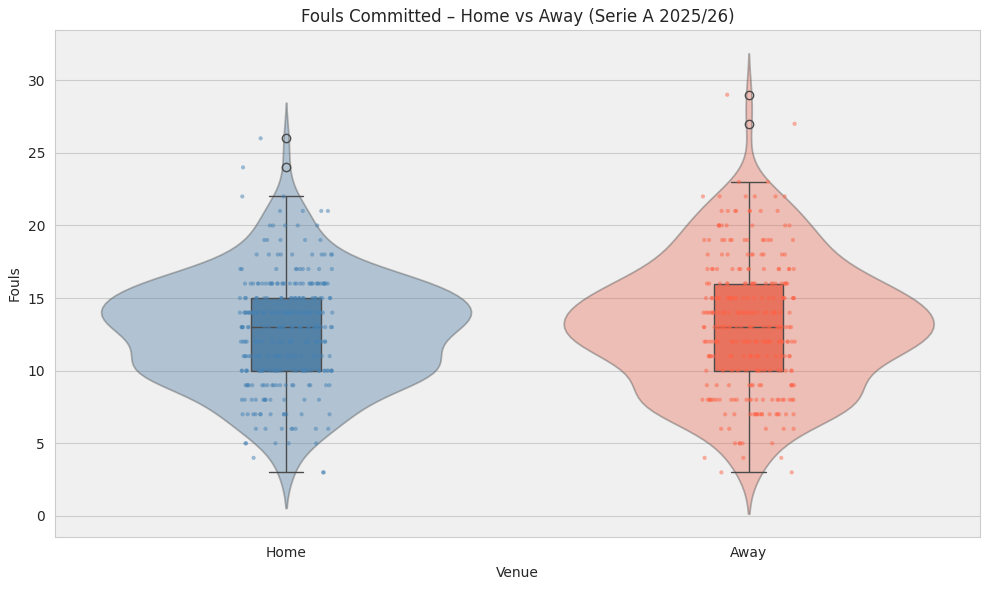

In [16]:
with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_facecolor('#f0f0f0')

    sns.violinplot(data=fouls_long, x='Venue', y='Fouls', hue='Venue',
                   palette={'Home': 'steelblue', 'Away': 'tomato'},
                   inner=None, alpha=0.4, legend=False, ax=ax)

    sns.boxplot(data=fouls_long, x='Venue', y='Fouls', hue='Venue',
                palette={'Home': 'steelblue', 'Away': 'tomato'},
                width=0.15, showcaps=True, legend=False,
                boxprops={'zorder': 2}, ax=ax)

    sns.stripplot(data=fouls_long, x='Venue', y='Fouls', hue='Venue',
                  palette={'Home': 'steelblue', 'Away': 'tomato'},
                  size=3, alpha=0.5, jitter=True, legend=False, ax=ax)

    ax.set_title('Fouls Committed – Home vs Away (Serie A 2025/26)')
    plt.tight_layout()


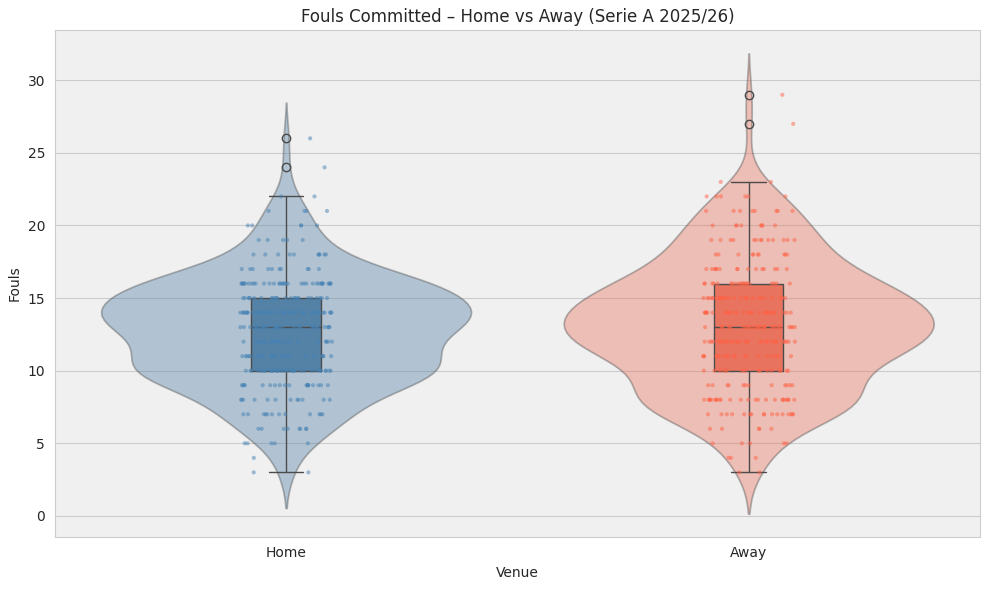

In [18]:
import ptitprince as pt

with sns.axes_style("whitegrid"):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_facecolor('#f0f0f0')

    sns.violinplot(data=fouls_long, x='Venue', y='Fouls', hue='Venue',
                   palette={'Home': 'steelblue', 'Away': 'tomato'},
                   inner=None, alpha=0.4, legend=False, ax=ax)

    sns.boxplot(data=fouls_long, x='Venue', y='Fouls', hue='Venue',
                palette={'Home': 'steelblue', 'Away': 'tomato'},
                width=0.15, showcaps=True, legend=False,
                boxprops={'zorder': 2}, ax=ax)

    sns.stripplot(data=fouls_long, x='Venue', y='Fouls', hue='Venue',
                  palette={'Home': 'steelblue', 'Away': 'tomato'},
                  size=3, alpha=0.5, jitter=True, legend=False, ax=ax)

    ax.set_title('Fouls Committed – Home vs Away (Serie A 2025/26)')
    plt.tight_layout()



In [33]:
ita_2526_all_matches_reduced.columns

Index(['HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HF', 'AF', 'HY', 'AY',
       'HR', 'AR', 'total_fouls', 'total_yellow_cards', 'total_red_cards'],
      dtype='str')

## Fouls mean

In [22]:
print(ita_2526_all_matches_reduced['total_fouls'].mean())
print(ita_2526_all_matches_reduced['HF'].mean())
print(ita_2526_all_matches_reduced['AF'].mean())

25.886666666666667
12.72
13.166666666666666


In [23]:
print(ita_2526_all_matches_reduced['total_fouls'].sum()/ita_2526_all_matches_reduced.shape[0])
print(ita_2526_all_matches_reduced['HF'].sum()/ita_2526_all_matches_reduced.shape[0])
print(ita_2526_all_matches_reduced['AF'].sum()/ita_2526_all_matches_reduced.shape[0])

25.886666666666667
12.72
13.166666666666666


In [25]:
def team_foul_stats(df):
    # Extract fouls when team plays at home
    home = df[['HomeTeam', 'HF']].rename(columns={'HomeTeam': 'team', 'HF': 'fouls'})
    home['venue'] = 'home'

    # Extract fouls when team plays away
    away = df[['AwayTeam', 'AF']].rename(columns={'AwayTeam': 'team', 'AF': 'fouls'})
    away['venue'] = 'away'

    long = pd.concat([home, away], ignore_index=True)

    # Overall stats
    overall = long.groupby('team')['fouls'].agg(
        total_fouls='sum',
        mean_fouls='mean',
        std_fouls='std'
    )

    # Home stats
    home_stats = long[long['venue'] == 'home'].groupby('team')['fouls'].agg(
        total_fouls_home='sum',
        mean_fouls_home='mean',
        std_fouls_home='std'
    )

    # Away stats
    away_stats = long[long['venue'] == 'away'].groupby('team')['fouls'].agg(
        total_fouls_away='sum',
        mean_fouls_away='mean',
        std_fouls_away='std'
    )

    result = pd.concat([overall, home_stats, away_stats], axis=1).reset_index()
    result = result.sort_values('total_fouls', ascending=False).round(2)

    return result


In [26]:
results = team_foul_stats(ita_2526_all_matches_reduced)

In [27]:
results.sort_values('total_fouls', ascending=False)

,team,total_fouls,mean_fouls,std_fouls,total_fouls_home,mean_fouls_home,std_fouls_home,total_fouls_away,mean_fouls_away,std_fouls_away
19,Verona,478.0,15.93,3.66,211.0,15.07,4.27,267.0,16.69,2.96
2,Cagliari,451.0,15.03,3.32,228.0,15.20,3.59,223.0,14.87,3.14
15,Roma,437.0,14.57,3.61,200.0,13.33,3.18,237.0,15.80,3.69
17,Torino,429.0,14.30,4.96,212.0,14.13,3.80,217.0,14.47,6.05
18,Udinese,424.0,14.13,3.90,223.0,14.87,2.80,201.0,13.40,4.75
3,Como,412.0,13.73,4.31,205.0,12.81,4.07,207.0,14.79,4.48
4,Cremonese,411.0,13.70,4.65,188.0,13.43,3.34,223.0,13.94,5.65
1,Bologna,409.0,13.63,4.17,189.0,12.60,3.16,220.0,14.67,4.88
7,Inter,406.0,13.53,5.36,205.0,13.67,4.89,201.0,13.40,5.96
14,Pisa,389.0,12.97,4.02,192.0,12.80,2.37,197.0,13.13,5.28


In [26]:
# Filter Italian Serie A, season 2526
ita_2526 = team_matches[
    (team_matches['league'] == 'Serie_A') & 
    (team_matches['season'] == '2526')
]

# Group by team and sum fouls
foul_summary = (
    ita_2526
    .groupby('team')[['fouls_committed', 'fouls_received']]
    .sum()
    .sort_values('fouls_committed', ascending=False)
    .reset_index()
)

foul_summary['diff'] = foul_summary['fouls_committed'] - foul_summary['fouls_received']
foul_summary.sort_values('fouls_committed', ascending = False)


,team,fouls_committed,fouls_received,diff
0,Verona,478.0,280.0,198.0
1,Cagliari,451.0,456.0,-5.0
2,Roma,437.0,435.0,2.0
3,Torino,429.0,315.0,114.0
4,Udinese,424.0,353.0,71.0
5,Como,412.0,371.0,41.0
6,Cremonese,411.0,401.0,10.0
7,Bologna,409.0,443.0,-34.0
8,Inter,406.0,339.0,67.0
9,Pisa,389.0,347.0,42.0


In [25]:
ita_2526

,season,date,team,opponent,yellow_cards,red_cards,fouls_committed,fouls_received,shots,shots_opponent,shots_on_target,shots_on_target_opponent,corners,corners_opponent,goals_scored,goals_conceded,match_result,venue,team_result,league
0,2526,23/08/2025,Genoa,Lecce,2.0,0.0,16.0,13.0,5.0,7.0,2.0,0.0,3.0,7.0,0.0,0.0,D,home,D,Serie_A
1,2526,23/08/2025,Sassuolo,Napoli,3.0,1.0,17.0,17.0,7.0,13.0,2.0,4.0,1.0,2.0,0.0,2.0,A,home,L,Serie_A
2,2526,23/08/2025,Milan,Cremonese,1.0,0.0,10.0,14.0,24.0,4.0,6.0,3.0,9.0,2.0,1.0,2.0,A,home,L,Serie_A
3,2526,23/08/2025,Roma,Bologna,1.0,0.0,15.0,13.0,14.0,10.0,4.0,2.0,2.0,4.0,1.0,0.0,H,home,W,Serie_A
4,2526,24/08/2025,Cagliari,Fiorentina,4.0,0.0,18.0,14.0,14.0,4.0,6.0,1.0,3.0,2.0,1.0,1.0,D,home,D,Serie_A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5913,2526,22/03/2026,Pisa,Como,2.0,0.0,6.0,5.0,7.0,14.0,0.0,7.0,1.0,7.0,0.0,5.0,H,away,L,Serie_A
5914,2526,22/03/2026,Verona,Atalanta,3.0,0.0,16.0,12.0,12.0,11.0,3.0,3.0,4.0,2.0,0.0,1.0,H,away,L,Serie_A
5915,2526,22/03/2026,Lazio,Bologna,1.0,0.0,8.0,13.0,9.0,15.0,5.0,4.0,1.0,2.0,2.0,0.0,A,away,W,Serie_A
5916,2526,22/03/2026,Lecce,Roma,2.0,0.0,17.0,14.0,8.0,14.0,3.0,2.0,2.0,10.0,0.0,1.0,H,away,L,Serie_A


In [6]:
all_matches.keys()

dict_keys(['Serie_A', 'Premier_League', 'La_Liga', 'Bundesliga', 'Ligue_1'])

In [7]:
df_serie_a = all_matches['Serie_A']
ita_2526 = df_serie_a[df_serie_a['season'] == '2526']

In [8]:
df_serie_a.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HF,...,AY,HR,AR,HS,AS,HST,AST,HC,AC,season
0,23/08/2025,Genoa,Lecce,0.0,0.0,D,0.0,0.0,D,16.0,...,3.0,0.0,0.0,5.0,7.0,2.0,0.0,3.0,7.0,2526
1,23/08/2025,Sassuolo,Napoli,0.0,2.0,A,0.0,1.0,A,17.0,...,1.0,1.0,0.0,7.0,13.0,2.0,4.0,1.0,2.0,2526
2,23/08/2025,Milan,Cremonese,1.0,2.0,A,1.0,1.0,D,10.0,...,4.0,0.0,0.0,24.0,4.0,6.0,3.0,9.0,2.0,2526
3,23/08/2025,Roma,Bologna,1.0,0.0,H,0.0,0.0,D,15.0,...,1.0,0.0,0.0,14.0,10.0,4.0,2.0,2.0,4.0,2526
4,24/08/2025,Cagliari,Fiorentina,1.0,1.0,D,0.0,0.0,D,18.0,...,2.0,0.0,0.0,14.0,4.0,6.0,1.0,3.0,2.0,2526


In [9]:
ita_2526.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,HF,...,AY,HR,AR,HS,AS,HST,AST,HC,AC,season
0,23/08/2025,Genoa,Lecce,0.0,0.0,D,0.0,0.0,D,16.0,...,3.0,0.0,0.0,5.0,7.0,2.0,0.0,3.0,7.0,2526
1,23/08/2025,Sassuolo,Napoli,0.0,2.0,A,0.0,1.0,A,17.0,...,1.0,1.0,0.0,7.0,13.0,2.0,4.0,1.0,2.0,2526
2,23/08/2025,Milan,Cremonese,1.0,2.0,A,1.0,1.0,D,10.0,...,4.0,0.0,0.0,24.0,4.0,6.0,3.0,9.0,2.0,2526
3,23/08/2025,Roma,Bologna,1.0,0.0,H,0.0,0.0,D,15.0,...,1.0,0.0,0.0,14.0,10.0,4.0,2.0,2.0,4.0,2526
4,24/08/2025,Cagliari,Fiorentina,1.0,1.0,D,0.0,0.0,D,18.0,...,2.0,0.0,0.0,14.0,4.0,6.0,1.0,3.0,2.0,2526
